# Objective

In this notebook, I'll be implementing a Deep Q Network (DQN) to solve the [Lunar Lander](https://gymnasium.farama.org/environments/box2d/lunar_lander/) environment. 

# Deep Q Learning

Unlike in previous environments, the observation/state space here is continuous, meaning it isn't possible to store values at each $(s, a)$ (there are infinite states $s$). Thus, the 'tabular' methods of previous environments wouldn't work.

A solution to this problem is to approximate $q(s,a)$ with a function. In the case of DQN, this function is a deep *neural network* (NN), meaning it has more than one hidden layer. The input to the network would be a state vector $s \in S$ sampled from the continuous state space, and the output would be a vector whose values are $q(s, a_i)$, where each $a_i \in \{a_1, ..., a_N\}$ is one of the $N$ possible discrete actions. **(Clearly, this method cannot deal with continuous action spaces.)**

We need a differentiable loss function to train this network using gradient descent. A smaller value of the loss corresponds to a better estimate of $q$. The optimality equation for $q$ is $$q(s, a) = r + \gamma \displaystyle \max_a' q(s', a'),$$ where $(r, s')$ are the reward and new state we get from taking action $a$ in state $s$. (This is also where the Q-learning update rule comes from.) Clearly, a good definition for the loss is $$\mathcal{L} := \Big(q(s, a) - \big( r + \gamma \displaystyle \max_a' q(s', a')\big)\Big)^2.$$

$\mathcal{L}=0$ corresponds to the optimal value function (since the solution to the Bellman equation is unique), and so minimizing $\mathcal{L}$ corresponds to the NN becoming a better estimate of $q$.

Notice that $q$ appears twice in the loss. This loss is unstable if used as-is (though I haven't seen a formal mathematical explanation as to why), so usually $q(s', a')$ is taken to be a copy of the network that gets synchronized with $q$ periodically. The period is a parameter of the DQN algorithm.

An important requirement for NN training is that the inputs (environment states) should be independent and identically distributed (iid). The sequence of states, actions and rewards is usually highly correlated, because states that follow one another are typically similar in some way. Thus, we cannot simply update the network with them like in Q-learning (where we didn't have this iid requirement). To train the DQN, we will play out episodes and store the results in a *replay buffer.* Then, during training, random batches of $(s, a, r, s')$ will be extracted from the buffer for training. The number of steps stored in the buffer (i.e. its length) is another hyperparameter of the algorithm.

# Lunar lander environment


In [1]:
import gymnasium as gym
from itertools import product
from collections import defaultdict, Counter, deque
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch

In [2]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode='rgb_array')

In [3]:
print(env.observation_space) # 8-dimensional vector, each component being continuous. The last two components
# represent booleans (whether spaceship legs touch ground or not), but we'll treat them as float values.

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [4]:
print(env.action_space) # 4 discrete actions to control motion of the lander.

Discrete(4)


In [5]:
# Let's see how making a batch of observations (states) looks like.
obs_list   = [env.observation_space.sample() for i in range(5)]
obs_tensor = torch.tensor(obs_list)
print(obs_list)
print("")
print(obs_tensor)

[array([-1.5106769 , -0.36635214, -0.5987596 ,  4.3803105 ,  0.46890023,
        2.4508991 ,  0.977432  ,  0.89835495], dtype=float32), array([-2.0212908 , -2.1418207 , -7.1755743 , -5.4439483 , -2.9249043 ,
       -1.887847  ,  0.1869695 ,  0.51442146], dtype=float32), array([ 2.387563  ,  1.2513101 ,  5.4102526 , -0.42463008, -4.48328   ,
        4.3649077 ,  0.02829092,  0.06090995], dtype=float32), array([-2.3994412 , -1.3556752 , -1.3304787 ,  0.98185146,  2.435643  ,
       -8.541019  ,  0.40459   ,  0.702544  ], dtype=float32), array([ 1.0782297 , -1.5604459 ,  3.0710695 ,  3.4791236 ,  0.6053747 ,
        2.8458872 ,  0.4674928 ,  0.99312013], dtype=float32)]

tensor([[-1.5107, -0.3664, -0.5988,  4.3803,  0.4689,  2.4509,  0.9774,  0.8984],
        [-2.0213, -2.1418, -7.1756, -5.4439, -2.9249, -1.8878,  0.1870,  0.5144],
        [ 2.3876,  1.2513,  5.4103, -0.4246, -4.4833,  4.3649,  0.0283,  0.0609],
        [-2.3994, -1.3557, -1.3305,  0.9819,  2.4356, -8.5410,  0.4046,  0.70

/tmp/ipykernel_11/3723761080.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  obs_tensor = torch.tensor(obs_list)


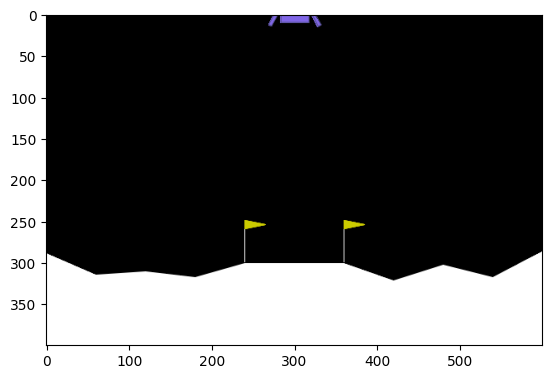

In [6]:
_ = env.reset()
frame = env.render()
plt.imshow(frame)
plt.show()

# Code

Based on the DQN discussion above, my main `Agent` class needs the following components:

- A buffer attribute to store $(s, a, r)$ data from episodes. Data should be added sequentially, since the state of the $i+1$-th entry is the new state $s'$ reached from entry $i$. The buffer must also have a fixed length, meaning that a) it should be filled up to said length by random actions at the start of training, and b) each new entry will take the place of the oldest entry ("kick" it out). For this purpose, `collections.deque` is quite handy.
- A Pytorch neural network to approximate $q$. This will come with an optimizer and loss function. The learning rate is yet another hyperparameter that we must keep track of and optimize.
- A function to extract batches of training data from the buffer. Each component of the batch contains $(s, a, r, s')$, used for training (next point).
- A training function. $q(s)$ is evaluated, and the output corresponding to $a$ is selected. Similarly, $q'(s')$ is calculated, where $q'$ is the unsychronized copy of the network. A max is taken over its outputs and the loss calculated as in the equation shown earlier. Backpropagation and optimizer stepping result in an updated estimate for $q$.
- A synchronizer, which sets the parameters of $q'$ to those of $q$ periodically. (The period is a hyperparameter of the algorithm.)
- A function to collect data from the environment (after the buffer has already been filled by random episodes). An $\epsilon$-greedy policy will be used, i.e. actions are chosen either randomly or greedily w.r.t. $q(s, a)$ estimate. Collected data is appended to the buffer.

The last bullet needs elaboration. When do we use our current estimate of $q$ to get more data, and when do we update it? In the following, **I choose to collect a batch of data with the current estimate, then update it with a batch of training data, and repeat**. Other schemes may be better, but this seems reasonable.

**Comment:** A big source of bugs in Pytorch model training is datatype mismatch between input tensors and model parameters. All tensors need to be the same datatype (e.g. torch.float32) and be on the same device (e.g. 'cuda').

In [7]:
# Showing how `collections.deque` works.
a = deque([], 5)
print(a)
for i in range(10):
    a.append(i)
    print(a)

deque([], maxlen=5)
deque([0], maxlen=5)
deque([0, 1], maxlen=5)
deque([0, 1, 2], maxlen=5)
deque([0, 1, 2, 3], maxlen=5)
deque([0, 1, 2, 3, 4], maxlen=5)
deque([1, 2, 3, 4, 5], maxlen=5)
deque([2, 3, 4, 5, 6], maxlen=5)
deque([3, 4, 5, 6, 7], maxlen=5)
deque([4, 5, 6, 7, 8], maxlen=5)
deque([5, 6, 7, 8, 9], maxlen=5)


In [8]:
import torch.nn as nn
import copy
class q_network(nn.Module):
    
    def __init__(self, hidden_size, n_features=8, n_actions=4):
        super().__init__()
        # I decided to have 2 hidden channels, each with the same size.
        self.lin1 = nn.Linear(in_features=n_features, out_features=hidden_size)
        self.lin2 = nn.Linear(in_features=hidden_size, out_features=hidden_size)
        self.lin3 = nn.Linear(in_features=hidden_size, out_features=n_actions)
        self.relu = nn.ReLU()
        
        # The network output is the value of q at (state, action) for each action. This is a 
        # regression problem, so there's no nonlinearity before the output.
        self.full_network = nn.Sequential(self.lin1, self.relu, self.lin2, self.relu, self.lin3)
        
    def forward(self, state):
        out = self.full_network(state)
        return out

In [9]:
10 % 3

1

In [10]:
np.linspace(10, 1, 5)

array([10.  ,  7.75,  5.5 ,  3.25,  1.  ])

In [11]:
class Agent:
    def __init__(self, env, network, optimizer, gamma, min_eps, max_n_updates,
                 buffer_length, batch_size, device, sync_period):
        self.gamma         = gamma
        self.batch_size    = batch_size
        self.env           = env
        self.buffer_length = buffer_length
        self.device        = device
        self.sync_period   = sync_period
        self.nn            = network.float() # Setting this to float32, otherwise we get errors.
        self.nn.to(device)
        self.async_nn      = copy.deepcopy(network)
        self.async_nn.to(device)
        self.loss_fn       = nn.MSELoss()
        self.optimizer     = optimizer
        self.buffer        = deque(maxlen=buffer_length)
        
        # We need a counter of update steps, for network syncing.
        self.update_counter = 0
        
        # Below variables are for epsilon-greedy action selection scheme.
        self.eps_list = np.linspace(1, min_eps, max_n_updates)
        
        
    def fill_buffer(self):
        while len(self.buffer) < self.buffer_length:
            # Initialize variables for next episode.
            state, _ = self.env.reset()
            done     = False
            
            # Play an episode.
            while not done:
                # Pick action and append (s, a, r) to buffer.
                action = self.env.action_space.sample()
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                self.buffer.append((state, action, reward))
                done = terminated or truncated
                
                # Update current state.
                state = new_state
                
                # Break loop if buffer is filled.
                if len(self.buffer) >= self.buffer_length:
                    break
        
    def sync_networks(self):
        if self.update_counter % self.sync_period == 0:
            self.async_nn.load_state_dict(self.nn.state_dict())
        
        
    def get_train_data(self):
        # Get indices for (s, a) pairs.
        data_inds  = np.random.randint(0, self.buffer_length-1, size=self.batch_size)
        new_s_inds = data_inds + 1
        
        # Extract a list of (s, a, r), (s') from the buffer. Make separate lists of s, s', a and r.
        sar_list     = [self.buffer[data_ind] for data_ind in data_inds]
        s_list       = [sar_tuple[0] for sar_tuple in sar_list]
        s_tensor     = torch.tensor(s_list)
        a_list       = [sar_tuple[1] for sar_tuple in sar_list]
        a_tensor     = torch.tensor(a_list).unsqueeze(1)
        r_list       = [sar_tuple[2] for sar_tuple in sar_list]
        r_tensor     = torch.tensor(r_list).unsqueeze(1)
        s_prime_list = [self.buffer[data_ind] for data_ind in new_s_inds]
        s_prime_list = [sar_tuple[0] for sar_tuple in s_prime_list]
        s_prime_tensor = torch.tensor(s_prime_list)
        
        # Send tensors to device, set precision and return.
        s_tensor       = s_tensor.to(device).float()
        r_tensor       = r_tensor.to(device).float()
        s_prime_tensor = s_prime_tensor.to(device).float()
        return s_tensor.to(device), a_tensor.to(device), r_tensor.to(device), s_prime_tensor.to(device)
        
        
    def update_q(self):
        # Clear optimizer.
        self.optimizer.zero_grad()
        
        # Prepare data for loss calculation.
        s_tensor, a_tensor, r_tensor, s_prime_tensor = self.get_train_data()
        qa_tensor_full = self.nn(s_tensor)
        with torch.no_grad():
            qa_prime_tensor_full = self.async_nn(s_prime_tensor).detach()
            
#         # Prints for debugging.
#         print("Debug prints in `update_q`.")
#         print(f"s_tensor: {s_tensor.dtype}.")
#         print(f"a_tensor: {a_tensor.dtype}.")
#         print(f"r_tensor: {r_tensor.dtype}.")
#         print(f"qa_tensor_full: {qa_tensor_full.dtype}.")
#         print(f"qa_prime_tensor_full: {qa_prime_tensor_full.dtype}.")
#         print("###########################")
        
        # `qa_tensor_full` and `qa_prime_tensor_full` are batch_size x n_actions tensors. Each row corresponds to
        # q(s, a_i) for i=0->3. We only want q(s, action) for action in a_tensor, whereas for qa_prime_tensor_full
        # we want the column corresponding to the highest value of q. We do this below. TODO: reword better.
        qa_tensor          = torch.gather(qa_tensor_full, 1, a_tensor)
        qa_prime_tensor, _ = torch.max(qa_prime_tensor_full, axis=1)
        qa_prime_tensor = qa_prime_tensor.unsqueeze(1) # Makes it from (256,) to (256, 1).
            
        # Calculate loss.
        target = r_tensor + self.gamma * qa_prime_tensor
#         print("###")
#         print(f"r_tensor: {r_tensor.shape}")
#         print(f"qa_prime_tensor: {qa_prime_tensor.shape}")
#         print(f"target: {target.shape}")
#         print(f"qa: {qa_tensor.shape}")
        loss = self.loss_fn(qa_tensor, target)
        
        # Backpropagate and update parameters.
        loss.backward()
        optimizer.step()
        
        # Update counter.
        self.update_counter += 1
        
    def choose_action(self, state):
        # Check `state` is an array or tensor.
        if type(state) is np.ndarray:
            state = torch.tensor(state, dtype=torch.float).to(self.device)
        elif type(state) is torch.Tensor:
            pass
        else:
            raise Exception(f"State is {type(state)}, expected npdarray or Tensor.")
        
        p = np.random.uniform()
        eps = self.eps_list[min(self.update_counter, len(self.eps_list)-1)]
        if p < eps: # Choose randomly.
            action = self.env.action_space.sample()
        else:            # Choose best action for current state.
            with torch.no_grad():
                q_list = self.nn(state)
            action = int(torch.argmax(q_list))

        return action
    
    def get_data_from_env(self):
        # We want `batch_size` datapoints. Since episodes don't have fixed duration, we'll
        # need a loop break condition.
        n_datapoints = 0
        while n_datapoints < self.batch_size:
            
            # Initialize variables for next episode.
            state, _ = self.env.reset()
            done     = False
            
            # Play an episode.
            while not done:
                
                # Start by selecting an action using epsilon-greedy policy.
                action = self.choose_action(state)
                
                # Step with action and collect results into buffer.
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                self.buffer.append((state, action, reward))
                done = terminated or truncated
                
                # Update current state.
                state = new_state
                
                # Update datapoints collection counter. If it exceeds `batch_size`, break loop.
                n_datapoints += 1
                if n_datapoints >= self.batch_size:
                    break
                    
    def play_one_episode(self):
        # Play a full episode and return total return and number of steps (episode duration). This function is
        # for evaluation purposes, so actions are ALWAYS selected greedily w.r.t. q.
        state, _  = self.env.reset()
        done      = False
        n_steps   = 0
        ep_return = 0 # Undiscounted return.
        
        while not done:
            # Convert `state` to a torch Tensor.
            state = torch.tensor(state, dtype=torch.float).to(self.device)
            
            # Select greedy action.
            with torch.no_grad():
                q_list = self.nn(state)
            action = int(torch.argmax(q_list))
            
            # Step with action.
            new_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated

            # Update current state, return and number of episode steps.
            state = new_state
            ep_return += reward
            n_steps   += 1
            
        return float(ep_return), n_steps

Time to set up the main training loop below. We will track training metrics as we did in the Q-learning notebook, i.e. we'll play episodes and record their total return (undiscounted). 

In [12]:
2**9

512

In [13]:
# Initialize environment.
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5)

# Initialize training hyperparams.
lr = 0.01
gamma = 1.0 # No discounting.
min_eps = 0.01
batch_size = 256
buffer_length = batch_size * 100
max_n_updates = 1000 # Note we can have more than this; this variable mainly controls epsilon reduction during training.
sync_period = 5
device = 'cuda'

# Initialize network and optimizer.
model = q_network(hidden_size=25)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Initialize lists to store training metrics: episode return, episode duration and iteration/update step.
return_list   = []
step_list     = []
duration_list = []

agent = Agent(env, model, optimizer, gamma, min_eps, max_n_updates,
                 buffer_length, batch_size, device, sync_period)

With the above scheme, we are updating the $q$ estimate 1,000 times at least. Each iteration includes collection of 256 new training data instances, and the training batches have a size of 256 also. 

**Question**: What takes the longest time here? Before making the proper training loop, I'll make a different loop to measure the times each operation takes.

In [71]:
import time
# Time tracking lists. 
t_update = []
t_metric = []
t_data   = []
t_total  = []


actual_n_updates = 3 * max_n_updates
# Start by filling up the buffer.
agent.fill_buffer()
for _ in range(50):
    print(agent.update_counter)
    # Update q.
    start_tot = time.time()
    starttime = time.time()
    agent.update_q()
    endtime   = time.time()
    t_update.append(endtime - starttime)

    starttime = time.time()
    # Gather training metrics.
    current_ep_return_list, current_ep_step_list = [], []
    for _ in range(10):
        current_return, current_n_steps = agent.play_one_episode()
        current_ep_return_list.append(current_return)
        current_ep_step_list.append(current_n_steps)
        return_list.append(np.mean(current_ep_return_list))
        step_list.append(np.mean(current_ep_step_list))
    endtime   = time.time()
    t_metric.append(endtime - starttime)


    # Collect more data for the training buffer.
    starttime = time.time()
    agent.get_data_from_env()
    endtime   = time.time()
    t_data.append(endtime - starttime)
    end_tot = time.time()
    t_total.append(end_tot - start_tot)


In [61]:
print(f"Total time           : {np.mean(t_total):.2f}s.")
print(f"Update time          : {np.mean(t_update):.2f}s.")
print(f"Metric time          : {np.mean(t_metric):.2f}s.")
print(f"Data collection  time: {np.mean(t_data):.2f}s.")

Total time           : 0.79s.
Update time          : 0.01s.
Metric time          : 0.72s.
Data collection  time: 0.06s.


In [63]:
20*50

1000

Metric collection accounts for over 90% of the training time, which obviously won't fly. Instead of collecting metrics every time we update $q$, we could instead do so every 20 updates. That still gives us 50 datapoints at least, which is good. (Since I set `actual_n_updates = 3 * max_n_updates` for now, we'll actually have 150 datapoints, which is a good amount.)

In [70]:
import time
# Time tracking lists. 
t_update = []
t_metric = []
t_data   = []
t_total  = []


actual_n_updates = 3 * max_n_updates
# Start by filling up the buffer.
agent.fill_buffer()
for _ in range(200):
    print(agent.update_counter)
    # Update q.
    start_tot = time.time()
    starttime = time.time()
    agent.update_q()
    endtime   = time.time()
    t_update.append(endtime - starttime)

    starttime = time.time()
    # Gather training metrics.
    if agent.update_counter % 20 == 0:
        current_ep_return_list, current_ep_step_list = [], []
        for _ in range(10):
            current_return, current_n_steps = agent.play_one_episode()
            current_ep_return_list.append(current_return)
            current_ep_step_list.append(current_n_steps)
            return_list.append(np.mean(current_ep_return_list))
            step_list.append(np.mean(current_ep_step_list))
    endtime   = time.time()
    t_metric.append(endtime - starttime)


    # Collect more data for the training buffer.
    starttime = time.time()
    agent.get_data_from_env()
    endtime   = time.time()
    t_data.append(endtime - starttime)
    end_tot = time.time()
    t_total.append(end_tot - start_tot)


In [66]:
print(f"Total time           : {np.mean(t_total):.2f}s.")
print(f"Update time          : {np.mean(t_update):.2f}s.")
print(f"Metric time          : {np.mean(t_metric):.2f}s.")
print(f"Data collection  time: {np.mean(t_data):.2f}s.")

Total time           : 0.11s.
Update time          : 0.00s.
Metric time          : 0.04s.
Data collection  time: 0.07s.


Metrics still take more than 30% of training time, but we've achieved a speedup of roughly 7x. I'll further reduce the number of episodes per metric from 10 to 8; while there's a lot of variance in their durations and rewards, I think this will be ok. In principle, once the $q$ approximation improves we may expect the variance in reward and duration to decrease; that's something to check for in the graphs later.

Anyways, let's try to get some training done now.

In [14]:
# Initialize environment.
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5)

# Initialize training hyperparams.
lr = 0.01
gamma = 1.0 # No discounting.
min_eps = 0.01
batch_size = 256
buffer_length = batch_size * 100
max_n_updates = 1000 # Note we can have more than this; this variable mainly controls epsilon reduction during training.
sync_period = 5
device = 'cuda'

# Initialize network and optimizer.
model = q_network(hidden_size=25)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Initialize lists to store training metrics: episode return, episode duration and iteration/update step.
return_list   = []
step_list     = []
duration_list = []

agent = Agent(env, model, optimizer, gamma, min_eps, max_n_updates,
                 buffer_length, batch_size, device, sync_period)

In [16]:
# Start the main loop. Tqdm tracks progress.
actual_n_updates = 3 * max_n_updates
with tqdm(total=actual_n_updates) as pbar:
    # Start by filling up the buffer.
    agent.fill_buffer()
    while agent.update_counter < actual_n_updates: # Epsilon will have its lowest value from `max_n_updates` onward.
#         print(agent.update_counter)
        # Update q.
        agent.update_q()
        pbar.update(1)
        
        # Gather training metrics.
        current_ep_return_list, current_ep_step_list = [], []
        if agent.update_counter % 20 == 0:
            for _ in range(8):
                current_return, current_n_steps = agent.play_one_episode()
                current_ep_return_list.append(current_return)
                current_ep_step_list.append(current_n_steps)
            return_list.append(np.mean(current_ep_return_list))
            step_list.append(np.mean(current_ep_step_list))
        
        # Collect more data for the training buffer.
        agent.get_data_from_env()


100%|███████████████████████████████████████████████████████████████████████████████| 3000/3000 [12:09<00:00,  4.11it/s]


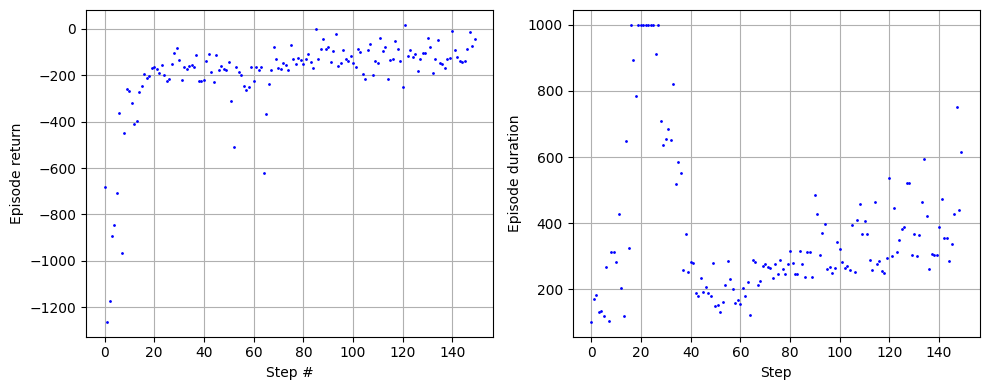

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
_ = [ax.grid(visible=True) for ax in axes]
axes[0].plot(np.arange(len(return_list)), return_list, 'bo', markersize=1)
axes[0].set_xlabel("Step #")
axes[0].set_ylabel("Episode return")
axes[1].plot(np.arange(len(step_list)), step_list, 'bo', markersize=1)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Episode duration")
plt.tight_layout()
plt.show()

In [22]:
agent.eps_list[-1] = 0

np.float64(0.01)

In [30]:
from IPython.display import Video
import imageio

video_env    = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode='rgb_array')
video_dir    = 'videos'
fps          = 60
agent.eps_list[-1] = 0  # Disable random, exploratory action selection for the agent.

for i in range(5): # We'll record 5 episodes.
    state, _    = video_env.reset()
    frames_list = []
    done        = False
    
    # Play an episode.
    while not done:
        action = agent.choose_action(state)
        state, _, terminated, truncated, _ = video_env.step(action)
#         print(state)
        frame  = video_env.render()
        frames_list.append(frame)
        done = terminated or truncated
        
    # Repeat the last frame 'fps' times. My video app cuts to black instantly, so I can't see it otherwise.
    frames_list.extend([frame]*fps)
        
    # Save the video. Repeat the last frame a few times (my video app cuts to black immediately, so I miss it otherwise).
    imageio.mimsave(f'{video_dir}/lunar_lander_{i}.mp4', frames_list, fps=fps, macro_block_size=1)

In [29]:
Video("videos/lunar_lander_0.mp4", embed=True)

## Comments

We see that episode return increases sharply at first, then appears to plateau out. Between update steps 40 and 140, return only increased by about 100 points on average, and the highest return is still in the negatives. From the lunar lander page, "An episode is considered a solution if it scores at least 200 points." We are still quite far off from that. 

From the video recording above, we see the network trying to balance the rocket by constantly swapping which side thrusters it fires. It did not manage to land in the middle.

In [31]:
Video("videos/lunar_lander_2.mp4", embed=True)

In this second example, we see a similar oscillation of opposite thrusters firing, but this time it lands in the correct spot.

## Longer training

I'm going to increase the duration of training to see if that helps. Longer training also means that $\epsilon$ will be larger for longer, so the network has more opportunities to explore. I will also increase the value of smallest $\epsilon$ by 10 times. 

In [32]:
# Initialize environment.
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5)

# Initialize training hyperparams.
lr = 0.01
gamma = 1.0 # No discounting.
min_eps = 0.1
batch_size = 256
buffer_length = batch_size * 100
max_n_updates = 2000 # Note we can have more than this; this variable mainly controls epsilon reduction during training.
sync_period = 5
device = 'cuda'

# Initialize network and optimizer.
model = q_network(hidden_size=25)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Initialize lists to store training metrics: episode return, episode duration and iteration/update step.
return_list   = []
step_list     = []
duration_list = []

agent = Agent(env, model, optimizer, gamma, min_eps, max_n_updates,
                 buffer_length, batch_size, device, sync_period)

In [33]:
# Start the main loop. Tqdm tracks progress.
actual_n_updates = 3 * max_n_updates
with tqdm(total=actual_n_updates) as pbar:
    # Start by filling up the buffer.
    agent.fill_buffer()
    while agent.update_counter < actual_n_updates: # Epsilon will have its lowest value from `max_n_updates` onward.
#         print(agent.update_counter)
        # Update q.
        agent.update_q()
        pbar.update(1)
        
        # Gather training metrics.
        current_ep_return_list, current_ep_step_list = [], []
        if agent.update_counter % 40 == 0:
            for _ in range(8):
                current_return, current_n_steps = agent.play_one_episode()
                current_ep_return_list.append(current_return)
                current_ep_step_list.append(current_n_steps)
            return_list.append(np.mean(current_ep_return_list))
            step_list.append(np.mean(current_ep_step_list))
        
        # Collect more data for the training buffer.
        agent.get_data_from_env()


100%|███████████████████████████████████████████████████████████████████████████████| 6000/6000 [22:54<00:00,  4.37it/s]


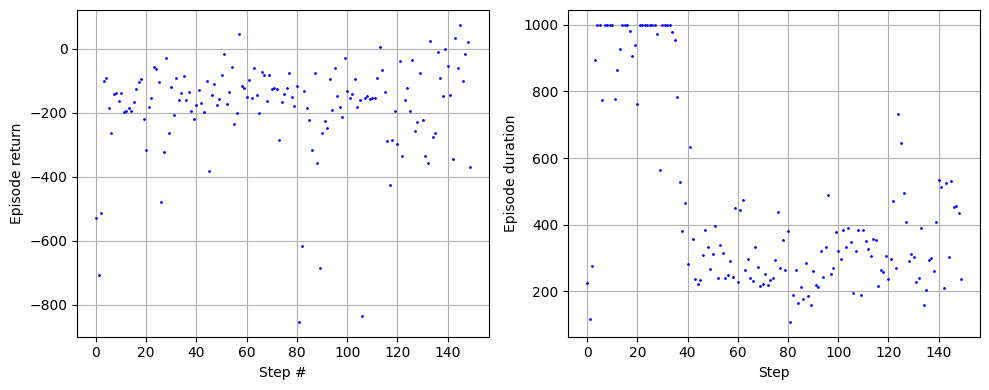

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
_ = [ax.grid(visible=True) for ax in axes]
axes[0].plot(np.arange(len(return_list)), return_list, 'bo', markersize=1)
axes[0].set_xlabel("Step #")
axes[0].set_ylabel("Episode return")
axes[1].plot(np.arange(len(step_list)), step_list, 'bo', markersize=1)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Episode duration")
plt.tight_layout()
plt.show()

In [41]:
from IPython.display import Video
import imageio

video_env    = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode='rgb_array')
video_dir    = 'videos'
fps          = 60
agent.eps_list[-1] = 0  # Disable random, exploratory action selection for the agent.

for i in range(5): # We'll record 5 episodes.
    state, _    = video_env.reset()
    frames_list = []
    done        = False
    landed_safe = None # Tracks if the lander landed or crashed in the episode.
    episode_return = 0
    
    # Play an episode.
    while not done:
        action = agent.choose_action(state)
        state, reward, terminated, truncated, _ = video_env.step(action)
        episode_return += reward
#         print(state)
        frame  = video_env.render()
        frames_list.append(frame)
        done = terminated or truncated
        
        # Update crash status.
        if reward == 100:
            landed_safe = 'Landed'
            print(landed_safe)
        elif reward == -100:
            landed_safe = 'Crashed'
            print(landed_safe)
        
    # Repeat the last frame 'fps' times. My video app cuts to black instantly, so I can't see it otherwise.
    frames_list.extend([frame]*fps)
        
    # Save the video. Repeat the last frame a few times (my video app cuts to black immediately, so I miss it otherwise).
    imageio.mimsave(f'{video_dir}/lunar_lander_{i}_{landed_safe}_return={episode_return:.1f}.mp4',
                    frames_list, fps=fps, macro_block_size=1)

Crashed
Crashed
Crashed
Crashed
Crashed


In [42]:
Video("videos/lunar_lander_0_Crashed_return=-412.1.mp4", embed=True)

In [43]:
Video("videos/lunar_lander_4_Crashed_return=-194.1.mp4", embed=True)

In most of the recorded episodes (including the first shown above), the network turns its engines off as quickly as possible so that the lander can crash between the flags. Unfortunately, most of the time it doesn't land on its feet. We see that the undiscounted episode returns are in the -200 to -400 range, which is not good. Interestingly in training we had some episodes with high return, but we are not able to replicate them here so they are rare.

# Next steps

There are mainly 3 things I want to do in future drafts:

1) Make general improvements to the code; e.g. $\epsilon$ values should not depend on the total length of training, like they presently do. Fixing these issues makes it easier to select hyperparameters.
2) Do a hyperparameter search. There are a vast number of hyperparameters that need to be tuned such as:
    - neural network architecture
    - batch size
    - discount factor $\gamma$
    - $\epsilon$ decay schedule
    - learning rate $\alpha$
    - number of times a batch of data is used to update $q$ (presently, one time per batch)
    - replay buffer size
    - total number of training steps
   In addition, I need to consider how often new data should be sampled for the buffer, and whether or not to use a prioritized replay buffer instead of a random one. (One scheme could be to weigh the probability of drawing a $(s, a, r, s')$ datapoint by the return of the episode it's a part of.)
3) Speed up training. I cannot hope to find optimal hyperparameters with how slow training is at present. Getting data from the environment is responsible for most of the training time, meaning the CPU is the bottleneck. It may be worth looking into multiprocessing. So long as we could make it "thread safe", it should provide a considerable speedup. 

Points 1 and 3 will likely be the focus of the next draft, and once an acceptable speedup is achieved (preferably over 10x), then we can do hyperparemeter search.

In [44]:
import os
os.cpu_count() # 16 logical cores, so multiprocessing may easily give us 10x speedup.

16

In [45]:
import psutil
psutil.cpu_count(logical=False) # 8 physical cores.

8

In [46]:
len(agent.buffer) # I'll try increasing it by 10x; RAM should be able to handle it. Also, decouple from batch size.

25600